# VIIRS SNPP vs NOAA-20: can we pool them for one bias correction?

Both VIIRS sensors yield very few collocated pairs after QA + spatial gating. This notebook tests whether SNPP and NOAA-20 are statistically distinguishable against AERONET. If not, we can concat them into one dataset and train a single CDF bias correction.

Three matched-pair sets per AERONET station:
1. **(AERONET, SNPP)**    — from `viirs_snpp_<site>.csv`
2. **(AERONET, NOAA-20)** — from `viirs_noaa20_<site>.csv`
3. **(SNPP, NOAA-20)**    — from gridded NetCDFs where both sensors land in the AERONET cell on the same day

Diagnostics:
- Bias and slope (vs AERONET) with 95% CIs — do the CIs overlap between sensors?
- SNPP vs NOAA-20 directly: bias, RMSE, R². If their RMSE is small vs each sensor's RMSE-vs-AERONET, residual sensor-specific bias is in the noise.
- Two-sample KS test on each sensor's AOD distribution at AERONET cells.

In [1]:
from __future__ import annotations
import sys, glob
from pathlib import Path
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, str(Path.cwd()))
from config import AERONET_SITES, LATS, LONS, COLLOCATE_DIR, GRIDDED_DIR

print('AERONET sites:', list(AERONET_SITES))
print('Grid:', len(LATS), 'x', len(LONS))
print('Collocated dir:', COLLOCATE_DIR)
print('Gridded dir:   ', GRIDDED_DIR)

AERONET sites: ['NGHIA_DO', 'Bac_Lieu']
Grid: 310 x 160
Collocated dir: /home/slow_data/Air_Quality/Stage_A/collocated
Gridded dir:    /home/slow_data/Air_Quality/Stage_A/gridded


## 1. Helpers

In [2]:
def cell_index(lat: float, lon: float) -> tuple[int, int]:
    return int(np.argmin(np.abs(LATS - lat))), int(np.argmin(np.abs(LONS - lon)))


def pair_stats(sat: np.ndarray, ref: np.ndarray, label_sat: str, label_ref: str) -> dict:
    """Bias, RMSE, R, OLS slope/intercept with 95% CIs (sat = slope*ref + intercept)."""
    sat = np.asarray(sat, dtype=float)
    ref = np.asarray(ref, dtype=float)
    m = np.isfinite(sat) & np.isfinite(ref)
    sat, ref = sat[m], ref[m]
    n = len(sat)
    if n < 3:
        return dict(n=n, label_sat=label_sat, label_ref=label_ref, error='n<3')
    diff = sat - ref
    bias = float(np.mean(diff))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    r = float(np.corrcoef(sat, ref)[0, 1])
    bias_se = float(np.std(diff, ddof=1) / np.sqrt(n))
    tcrit = float(stats.t.ppf(0.975, df=n - 1))
    bias_ci = (bias - tcrit * bias_se, bias + tcrit * bias_se)
    lr = stats.linregress(ref, sat)
    tcrit2 = float(stats.t.ppf(0.975, df=n - 2))
    slope_ci = (lr.slope - tcrit2 * lr.stderr, lr.slope + tcrit2 * lr.stderr)
    int_ci = (lr.intercept - tcrit2 * lr.intercept_stderr,
              lr.intercept + tcrit2 * lr.intercept_stderr)
    return dict(
        label_sat=label_sat, label_ref=label_ref, n=n,
        bias=bias, bias_ci=bias_ci, rmse=rmse, r=r, r2=r * r,
        slope=float(lr.slope), slope_ci=slope_ci,
        intercept=float(lr.intercept), intercept_ci=int_ci,
    )


def fmt_stats(s: dict) -> str:
    if s.get('error'):
        return f"  {s['label_sat']:>14s} vs {s['label_ref']:<10s}  n={s['n']}  -- {s['error']}"
    return (f"  {s['label_sat']:>14s} vs {s['label_ref']:<10s}  n={s['n']:3d}  "
            f"bias={s['bias']:+.3f} [{s['bias_ci'][0]:+.3f},{s['bias_ci'][1]:+.3f}]  "
            f"slope={s['slope']:.3f} [{s['slope_ci'][0]:.3f},{s['slope_ci'][1]:.3f}]  "
            f"RMSE={s['rmse']:.3f}  R²={s['r2']:.3f}")


def ci_overlap(a: tuple[float, float], b: tuple[float, float]) -> bool:
    return not (a[1] < b[0] or b[1] < a[0])

## 2. Load AERONET collocations

In [3]:
def load_collo(sensor: str, site: str) -> pd.DataFrame:
    df = pd.read_csv(COLLOCATE_DIR / f'{sensor}_{site}.csv',
                     parse_dates=['date', 'timestamp_aeronet', 'timestamp_satellite'])
    df['day'] = df['date'].dt.normalize()
    return df


collo: dict[tuple[str, str], pd.DataFrame] = {}
for site in AERONET_SITES:
    for sensor in ('viirs_snpp', 'viirs_noaa20'):
        collo[(sensor, site)] = load_collo(sensor, site)
        print(sensor, site, '->', len(collo[(sensor, site)]), 'rows')

viirs_snpp NGHIA_DO -> 196 rows
viirs_noaa20 NGHIA_DO -> 204 rows
viirs_snpp Bac_Lieu -> 210 rows
viirs_noaa20 Bac_Lieu -> 206 rows


## 3. Per-day SNPP ↔ NOAA-20 pairs at the AERONET cell

Walk gridded NetCDFs, sample both sensors at each AERONET cell, and aggregate to one value per sensor per day. A pair is kept only when both sensors produced a finite value at that cell that day.

In [4]:
def scan_gridded_for_both(verbose: bool = True) -> pd.DataFrame:
    cells = {s: cell_index(info['lat'], info['lon']) for s, info in AERONET_SITES.items()}
    rows: list[dict] = []
    all_files = sorted(glob.glob(str(GRIDDED_DIR / '*' / '*' / '*' / 'gridded_*.nc')))
    if verbose:
        print(f'scanning {len(all_files)} gridded files...')
    kept = 0
    for fpath in all_files:
        try:
            with nc.Dataset(fpath) as ds:
                vars_ = ds.variables
                if 'AOD_viirs_snpp' not in vars_ or 'AOD_viirs_noaa20' not in vars_:
                    continue
                slot = ds.getncattr('slot_utc') if 'slot_utc' in ds.ncattrs() else None
                snpp = vars_['AOD_viirs_snpp'][:]
                n20 = vars_['AOD_viirs_noaa20'][:]
        except Exception:
            continue
        if hasattr(snpp, 'filled'):
            snpp = snpp.filled(np.nan)
        if hasattr(n20, 'filled'):
            n20 = n20.filled(np.nan)
        for site, (i, j) in cells.items():
            s_val = float(snpp[i, j])
            n_val = float(n20[i, j])
            if np.isfinite(s_val) and np.isfinite(n_val):
                rows.append(dict(site=site, slot_utc=slot, snpp=s_val, noaa20=n_val))
                kept += 1
    if verbose:
        print(f'kept {kept} slot-level pairs')
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df['day'] = pd.to_datetime(df['slot_utc']).dt.normalize()
    return df


slot_pairs = scan_gridded_for_both()
slot_pairs.head()

scanning 26795 gridded files...
kept 33 slot-level pairs


,site,slot_utc,snpp,noaa20,day
0,NGHIA_DO,2022-10-12T06:00:00,0.112188,0.100304,2022-10-12
1,NGHIA_DO,2022-10-13T06:30:00,0.072215,0.435599,2022-10-13
2,NGHIA_DO,2022-10-18T06:30:00,0.361949,0.506891,2022-10-18
3,NGHIA_DO,2022-12-13T06:30:00,0.677434,0.372675,2022-12-13
4,NGHIA_DO,2022-12-21T06:30:00,0.857030,1.017675,2022-12-21


In [5]:
# Collapse to one value per sensor per (site, day)
if slot_pairs.empty:
    daily_pairs = slot_pairs
else:
    daily_pairs = (slot_pairs.groupby(['site', 'day'])
                              .agg(snpp=('snpp', 'mean'), noaa20=('noaa20', 'mean'),
                                   n_slots=('snpp', 'size'))
                              .reset_index())
print('daily SNPP↔NOAA-20 pairs at AERONET cells:')
print(daily_pairs.groupby('site').size())
daily_pairs.head()

daily SNPP↔NOAA-20 pairs at AERONET cells:
site
NGHIA_DO    26
dtype: int64


,site,day,snpp,noaa20,n_slots
0,NGHIA_DO,2022-10-12,0.112188,0.100304,1
1,NGHIA_DO,2022-10-13,0.072215,0.435599,1
2,NGHIA_DO,2022-10-18,0.361949,0.506891,1
3,NGHIA_DO,2022-12-13,0.677434,0.372675,1
4,NGHIA_DO,2022-12-21,0.857030,1.017675,1


## 4. Per-site comparison: SNPP vs AERONET, NOAA-20 vs AERONET, SNPP vs NOAA-20

In [6]:
results_per_site: dict[str, dict] = {}

for site in AERONET_SITES:
    snpp_df = collo[('viirs_snpp', site)]
    n20_df = collo[('viirs_noaa20', site)]
    s_aer = pair_stats(snpp_df['satellite_aod'].values, snpp_df['aeronet_aod'].values,
                       'SNPP', 'AERONET')
    n_aer = pair_stats(n20_df['satellite_aod'].values, n20_df['aeronet_aod'].values,
                       'NOAA20', 'AERONET')
    if not daily_pairs.empty:
        sub = daily_pairs[daily_pairs['site'] == site]
        s_n = pair_stats(sub['snpp'].values, sub['noaa20'].values, 'SNPP', 'NOAA20')
    else:
        s_n = dict(label_sat='SNPP', label_ref='NOAA20', n=0, error='no pairs')
    results_per_site[site] = dict(snpp_vs_aer=s_aer, n20_vs_aer=n_aer, snpp_vs_n20=s_n)

    print(f'\n=== {site} ===')
    print(fmt_stats(s_aer))
    print(fmt_stats(n_aer))
    print(fmt_stats(s_n))
    if 'error' not in s_aer and 'error' not in n_aer:
        bias_overlap = ci_overlap(s_aer['bias_ci'], n_aer['bias_ci'])
        slope_overlap = ci_overlap(s_aer['slope_ci'], n_aer['slope_ci'])
        print(f'  bias CIs overlap?  {bias_overlap}')
        print(f'  slope CIs overlap? {slope_overlap}')
        if 'error' not in s_n:
            ratio_s = s_n['rmse'] / s_aer['rmse']
            ratio_n = s_n['rmse'] / n_aer['rmse']
            print(f'  RMSE(SNPP↔N20) / RMSE(SNPP↔AER)  = {ratio_s:.2f}')
            print(f'  RMSE(SNPP↔N20) / RMSE(N20↔AER)   = {ratio_n:.2f}')


=== NGHIA_DO ===
            SNPP vs AERONET     n=196  bias=-0.021 [-0.060,+0.018]  slope=0.823 [0.750,0.897]  RMSE=0.278  R²=0.715
          NOAA20 vs AERONET     n=204  bias=-0.009 [-0.043,+0.025]  slope=1.006 [0.945,1.067]  RMSE=0.247  R²=0.841
            SNPP vs NOAA20      n= 26  bias=-0.028 [-0.101,+0.044]  slope=1.093 [0.937,1.250]  RMSE=0.178  R²=0.897
  bias CIs overlap?  True
  slope CIs overlap? False
  RMSE(SNPP↔N20) / RMSE(SNPP↔AER)  = 0.64
  RMSE(SNPP↔N20) / RMSE(N20↔AER)   = 0.72

=== Bac_Lieu ===
            SNPP vs AERONET     n=210  bias=+0.127 [+0.108,+0.145]  slope=0.839 [0.753,0.925]  RMSE=0.186  R²=0.640
          NOAA20 vs AERONET     n=206  bias=+0.097 [+0.081,+0.114]  slope=0.768 [0.703,0.834]  RMSE=0.156  R²=0.723
            SNPP vs NOAA20      n=0  -- n<3
  bias CIs overlap?  True
  slope CIs overlap? True


## 5. Pooled (both sites): the same three diagnostics on all data

In [7]:
snpp_all = pd.concat([collo[('viirs_snpp', s)] for s in AERONET_SITES], ignore_index=True)
n20_all = pd.concat([collo[('viirs_noaa20', s)] for s in AERONET_SITES], ignore_index=True)

pooled = dict(
    snpp_vs_aer=pair_stats(snpp_all['satellite_aod'].values, snpp_all['aeronet_aod'].values,
                            'SNPP', 'AERONET'),
    n20_vs_aer=pair_stats(n20_all['satellite_aod'].values, n20_all['aeronet_aod'].values,
                          'NOAA20', 'AERONET'),
    snpp_vs_n20=pair_stats(daily_pairs['snpp'].values, daily_pairs['noaa20'].values,
                            'SNPP', 'NOAA20') if not daily_pairs.empty
                else dict(label_sat='SNPP', label_ref='NOAA20', n=0, error='no pairs'),
)

print('=== pooled (both sites) ===')
for s in pooled.values():
    print(fmt_stats(s))

if 'error' not in pooled['snpp_vs_aer'] and 'error' not in pooled['n20_vs_aer']:
    print(f"  bias CIs overlap?  {ci_overlap(pooled['snpp_vs_aer']['bias_ci'], pooled['n20_vs_aer']['bias_ci'])}")
    print(f"  slope CIs overlap? {ci_overlap(pooled['snpp_vs_aer']['slope_ci'], pooled['n20_vs_aer']['slope_ci'])}")

=== pooled (both sites) ===
            SNPP vs AERONET     n=406  bias=+0.055 [+0.033,+0.078]  slope=0.785 [0.739,0.831]  RMSE=0.235  R²=0.733
          NOAA20 vs AERONET     n=410  bias=+0.044 [+0.025,+0.064]  slope=0.926 [0.887,0.965]  RMSE=0.206  R²=0.841
            SNPP vs NOAA20      n= 26  bias=-0.028 [-0.101,+0.044]  slope=1.093 [0.937,1.250]  RMSE=0.178  R²=0.897
  bias CIs overlap?  True
  slope CIs overlap? False


## 6. Two-sample KS test

Question: are the SNPP and NOAA-20 AOD distributions (at AERONET cells) statistically distinguishable?

Two views:
1. **Independent samples** — all SNPP AODs vs all NOAA-20 AODs from the AERONET-collocated CSVs.
2. **Same-day, same-cell pairs** — the SNPP and NOAA-20 columns of `daily_pairs` (controls for atmospheric variability).

In [8]:
print('--- KS test on independent collocated samples ---')
for site in AERONET_SITES:
    a = collo[('viirs_snpp', site)]['satellite_aod'].dropna().values
    b = collo[('viirs_noaa20', site)]['satellite_aod'].dropna().values
    ks = stats.ks_2samp(a, b)
    print(f'  {site:10s} n_snpp={len(a):3d}  n_n20={len(b):3d}  '
          f'D={ks.statistic:.3f}  p={ks.pvalue:.3g}  '
          f"{'-- distinguishable' if ks.pvalue < 0.05 else '-- not distinguishable'}")

ks_pool = stats.ks_2samp(snpp_all['satellite_aod'].dropna(), n20_all['satellite_aod'].dropna())
print(f'  POOLED     n_snpp={len(snpp_all):3d}  n_n20={len(n20_all):3d}  '
      f'D={ks_pool.statistic:.3f}  p={ks_pool.pvalue:.3g}')

print('\n--- KS test on same-day, same-cell pairs ---')
if not daily_pairs.empty:
    for site, sub in daily_pairs.groupby('site'):
        if len(sub) < 5:
            print(f'  {site:10s} n={len(sub)} -- too few')
            continue
        ks = stats.ks_2samp(sub['snpp'].values, sub['noaa20'].values)
        print(f'  {site:10s} n={len(sub):3d}  D={ks.statistic:.3f}  p={ks.pvalue:.3g}')
    ks_dp = stats.ks_2samp(daily_pairs['snpp'].values, daily_pairs['noaa20'].values)
    print(f'  POOLED     n={len(daily_pairs):3d}  D={ks_dp.statistic:.3f}  p={ks_dp.pvalue:.3g}')

--- KS test on independent collocated samples ---
  NGHIA_DO   n_snpp=196  n_n20=204  D=0.099  p=0.254  -- not distinguishable
  Bac_Lieu   n_snpp=210  n_n20=206  D=0.146  p=0.0205  -- distinguishable
  POOLED     n_snpp=406  n_n20=410  D=0.106  p=0.0182

--- KS test on same-day, same-cell pairs ---
  NGHIA_DO   n= 26  D=0.231  p=0.501
  POOLED     n= 26  D=0.231  p=0.501


## 7. Scatter plots

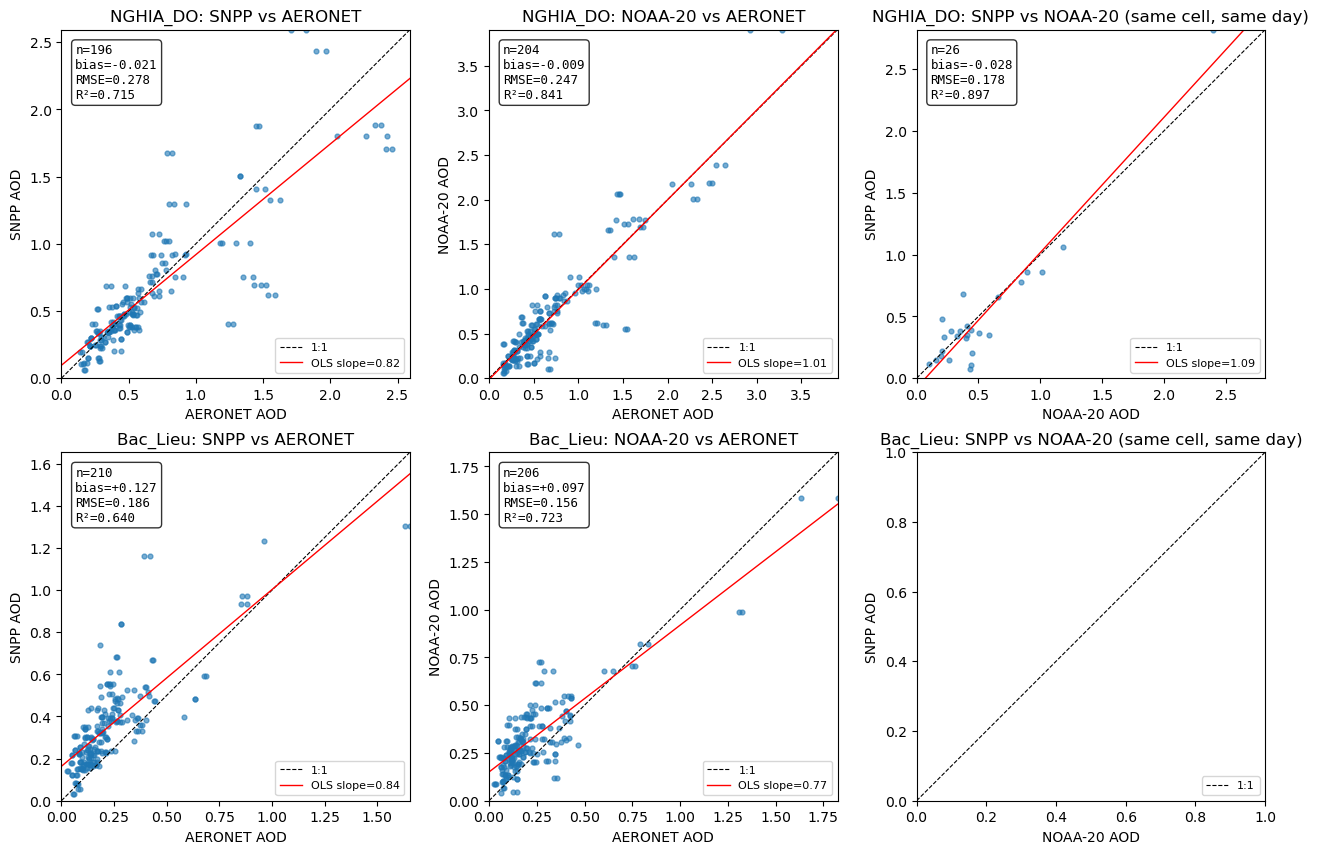

In [9]:
def scatter(ax, x, y, xlabel, ylabel, title, stats_dict=None):
    ax.scatter(x, y, s=12, alpha=0.6)
    lim = max(np.nanmax(x), np.nanmax(y)) if len(x) else 1.0
    lim = float(max(lim, 0.1))
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='1:1')
    if stats_dict and 'error' not in stats_dict:
        xs = np.linspace(0, lim, 50)
        ax.plot(xs, stats_dict['slope'] * xs + stats_dict['intercept'],
                'r-', lw=1, label=f"OLS slope={stats_dict['slope']:.2f}")
        ax.text(0.04, 0.96,
                f"n={stats_dict['n']}\nbias={stats_dict['bias']:+.3f}\n"
                f"RMSE={stats_dict['rmse']:.3f}\nR²={stats_dict['r2']:.3f}",
                transform=ax.transAxes, va='top', ha='left',
                fontsize=9, family='monospace',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(loc='lower right', fontsize=8)
    ax.set_aspect('equal')


n_sites = len(AERONET_SITES)
fig, axes = plt.subplots(n_sites, 3, figsize=(13, 4.3 * n_sites))
if n_sites == 1:
    axes = axes[np.newaxis, :]

for row, site in enumerate(AERONET_SITES):
    r = results_per_site[site]
    snpp_df = collo[('viirs_snpp', site)]
    n20_df = collo[('viirs_noaa20', site)]
    scatter(axes[row, 0],
            snpp_df['aeronet_aod'], snpp_df['satellite_aod'],
            'AERONET AOD', 'SNPP AOD',
            f'{site}: SNPP vs AERONET', r['snpp_vs_aer'])
    scatter(axes[row, 1],
            n20_df['aeronet_aod'], n20_df['satellite_aod'],
            'AERONET AOD', 'NOAA-20 AOD',
            f'{site}: NOAA-20 vs AERONET', r['n20_vs_aer'])
    if not daily_pairs.empty:
        sub = daily_pairs[daily_pairs['site'] == site]
        scatter(axes[row, 2],
                sub['noaa20'], sub['snpp'],
                'NOAA-20 AOD', 'SNPP AOD',
                f'{site}: SNPP vs NOAA-20 (same cell, same day)', r['snpp_vs_n20'])
    else:
        axes[row, 2].text(0.5, 0.5, 'no daily pairs', ha='center', va='center')
        axes[row, 2].set_axis_off()

plt.tight_layout()
plt.show()

## 8. CDF comparison at AERONET cells

If the empirical CDFs of SNPP and NOAA-20 AOD (at the AERONET cells) overlap closely, a single CDF bias correction trained on the pooled data is justified.

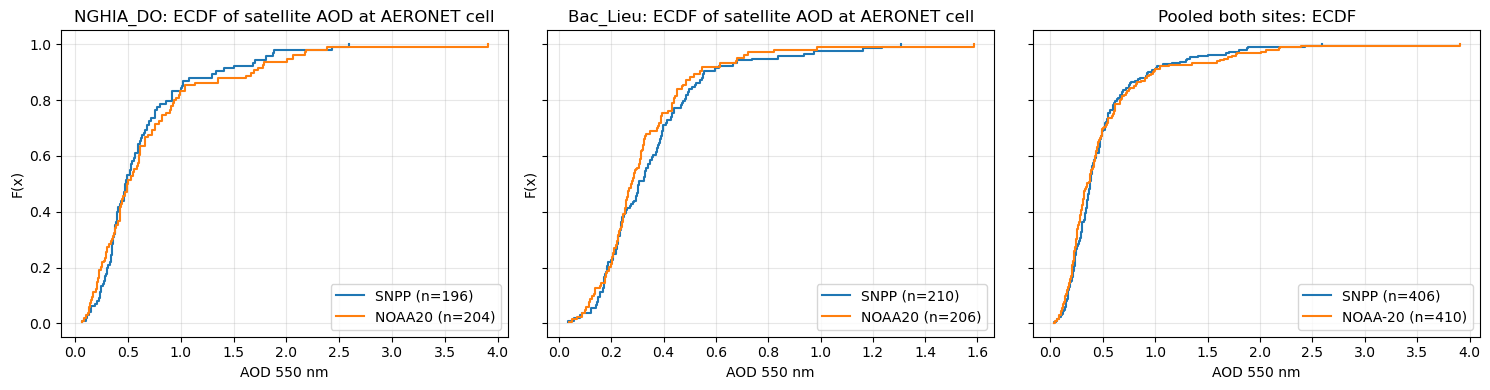

In [10]:
def ecdf(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x = np.sort(np.asarray(x, dtype=float))
    return x, np.arange(1, len(x) + 1) / len(x)


fig, axes = plt.subplots(1, len(AERONET_SITES) + 1,
                          figsize=(5 * (len(AERONET_SITES) + 1), 4), sharey=True)
for ax, site in zip(axes[:-1], AERONET_SITES):
    for sensor, color in [('viirs_snpp', 'C0'), ('viirs_noaa20', 'C1')]:
        vals = collo[(sensor, site)]['satellite_aod'].dropna().values
        if len(vals) == 0:
            continue
        x, y = ecdf(vals)
        ax.step(x, y, where='post', color=color,
                label=f'{sensor.replace("viirs_", "").upper()} (n={len(vals)})')
    ax.set_title(f'{site}: ECDF of satellite AOD at AERONET cell')
    ax.set_xlabel('AOD 550 nm'); ax.set_ylabel('F(x)')
    ax.grid(alpha=0.3); ax.legend()

# Pooled
ax = axes[-1]
for vals, label, color in [(snpp_all['satellite_aod'].dropna().values, 'SNPP', 'C0'),
                            (n20_all['satellite_aod'].dropna().values, 'NOAA-20', 'C1')]:
    x, y = ecdf(vals)
    ax.step(x, y, where='post', color=color, label=f'{label} (n={len(vals)})')
ax.set_title('Pooled both sites: ECDF')
ax.set_xlabel('AOD 550 nm')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

## 9. Verdict

Decision rule (apply per site and pooled):
- **Pool SNPP + NOAA-20** if **all** of:
  1. Bias CIs vs AERONET overlap.
  2. Slope CIs vs AERONET overlap.
  3. RMSE(SNPP↔NOAA-20) is small (≲ 0.5×) relative to either sensor's RMSE vs AERONET.
  4. KS test does not reject identical distributions (p > 0.05).
- **Keep separate** otherwise (sensor-specific bias is real and a single correction will under/over-correct one of them).

In [11]:
def verdict(snpp_vs_aer, n20_vs_aer, snpp_vs_n20, ks_p):
    if 'error' in snpp_vs_aer or 'error' in n20_vs_aer:
        return 'insufficient AERONET pairs'
    bias_ok = ci_overlap(snpp_vs_aer['bias_ci'], n20_vs_aer['bias_ci'])
    slope_ok = ci_overlap(snpp_vs_aer['slope_ci'], n20_vs_aer['slope_ci'])
    if 'error' not in snpp_vs_n20:
        ratio = snpp_vs_n20['rmse'] / max(snpp_vs_aer['rmse'], n20_vs_aer['rmse'])
        rmse_ok = ratio < 0.5
    else:
        ratio, rmse_ok = None, None
    ks_ok = ks_p > 0.05
    checks = [('bias CIs overlap', bias_ok),
              ('slope CIs overlap', slope_ok),
              (f'RMSE(SNPP↔N20) < 0.5× max RMSE-vs-AERONET (ratio={ratio:.2f})'
               if ratio is not None else 'RMSE check: no pairs', rmse_ok),
              (f'KS p>0.05 (p={ks_p:.3g})', ks_ok)]
    all_ok = all(c[1] for c in checks if c[1] is not None)
    return all_ok, checks


for site in AERONET_SITES:
    r = results_per_site[site]
    a = collo[('viirs_snpp', site)]['satellite_aod'].dropna().values
    b = collo[('viirs_noaa20', site)]['satellite_aod'].dropna().values
    ks_p = stats.ks_2samp(a, b).pvalue if len(a) and len(b) else 1.0
    v = verdict(r['snpp_vs_aer'], r['n20_vs_aer'], r['snpp_vs_n20'], ks_p)
    print(f'\n=== {site} ===')
    if isinstance(v, str):
        print('  ', v)
    else:
        all_ok, checks = v
        for label, ok in checks:
            mark = 'OK ' if ok else 'NO ' if ok is False else '-- '
            print(f'  [{mark}] {label}')
        print(f'  >>> {"POOL OK" if all_ok else "KEEP SEPARATE"}')

# Pooled across sites
ks_p_pool = stats.ks_2samp(snpp_all['satellite_aod'].dropna(),
                           n20_all['satellite_aod'].dropna()).pvalue
v = verdict(pooled['snpp_vs_aer'], pooled['n20_vs_aer'], pooled['snpp_vs_n20'], ks_p_pool)
print('\n=== POOLED (both sites) ===')
if isinstance(v, str):
    print('  ', v)
else:
    all_ok, checks = v
    for label, ok in checks:
        mark = 'OK ' if ok else 'NO ' if ok is False else '-- '
        print(f'  [{mark}] {label}')
    print(f'  >>> {"POOL OK" if all_ok else "KEEP SEPARATE"}')


=== NGHIA_DO ===
  [OK ] bias CIs overlap
  [NO ] slope CIs overlap
  [NO ] RMSE(SNPP↔N20) < 0.5× max RMSE-vs-AERONET (ratio=0.64)
  [OK ] KS p>0.05 (p=0.254)
  >>> KEEP SEPARATE

=== Bac_Lieu ===
  [OK ] bias CIs overlap
  [OK ] slope CIs overlap
  [-- ] RMSE check: no pairs
  [-- ] KS p>0.05 (p=0.0205)
  >>> KEEP SEPARATE

=== POOLED (both sites) ===
  [OK ] bias CIs overlap
  [NO ] slope CIs overlap
  [NO ] RMSE(SNPP↔N20) < 0.5× max RMSE-vs-AERONET (ratio=0.76)
  [-- ] KS p>0.05 (p=0.0182)
  >>> KEEP SEPARATE
